In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [45]:
from google.colab import files

uploaded = files.upload()

Saving subscription_usefulness_dataset (2).csv to subscription_usefulness_dataset (2) (2).csv


In [46]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [47]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
print(df.head())

print("\nColumns:")
print(df.columns)

Dataset Shape: (10000, 6)

First 5 Records:
   No         App_Name  Monthly_Cost_LKR  Usage_Minutes_30D      Label  \
0   1            Adobe              1713               1406  Low_Usage   
1   2  YouTube Premium              4824                408     Unused   
2   3        Grammarly              4137               2553     Useful   
3   4            Adobe              1599               2773     Useful   
4   5     ChatGPT Plus              1943               1772     Useful   

   Average_Daily_Usage_Minutes  
0                        46.87  
1                        13.60  
2                        85.10  
3                        92.43  
4                        59.07  

Columns:
Index(['No', 'App_Name', 'Monthly_Cost_LKR', 'Usage_Minutes_30D', 'Label',
       'Average_Daily_Usage_Minutes'],
      dtype='object')


In [51]:
print("Class Distribution:")
print(df["Label"].value_counts())

Class Distribution:
Label
Useful       3395
Low_Usage    3344
Unused       3261
Name: count, dtype: int64


In [52]:
X = df[
    [
        "Monthly_Cost_LKR",
        "Usage_Minutes_30D"
    ]
]

y = df["Label"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Monthly_Cost_LKR  Usage_Minutes_30D
0              1713               1406
1              4824                408
2              4137               2553
3              1599               2773
4              1943               1772

Target:
0    Low_Usage
1       Unused
2       Useful
3       Useful
4       Useful
Name: Label, dtype: object


In [53]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['Low_Usage' 'Unused' 'Useful']


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 8000
Testing Records: 2000


In [55]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 99.6 %


In [56]:
model.fit(
    X_train,
    y_train
)

print("XGBoost model training completed!")

XGBoost model training completed!


In [57]:
y_pred = model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [58]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 99.6 %


In [59]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

print("\nTotal test samples:", len(y_test))

print(
    "Correct predictions:",
    (y_test == y_pred).sum()
)

print(
    "Wrong predictions:",
    (y_test != y_pred).sum()
)

Confusion Matrix:
[[661   5   3]
 [  0 652   0]
 [  0   0 679]]

Total test samples: 2000
Correct predictions: 1992
Wrong predictions: 8


In [60]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

   Low_Usage       1.00      0.99      0.99       669
      Unused       0.99      1.00      1.00       652
      Useful       1.00      1.00      1.00       679

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [61]:
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
           Low_Usage  Unused  Useful
Low_Usage        661       5       3
Unused             0     652       0
Useful             0       0     679


In [62]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
             Feature  Importance
1  Usage_Minutes_30D    0.999189
0   Monthly_Cost_LKR    0.000811


In [63]:
import joblib

joblib.dump(
    model,
    "subscription_usefulness_xgboost.pkl"
)

joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Model saved successfully!")

Model saved successfully!


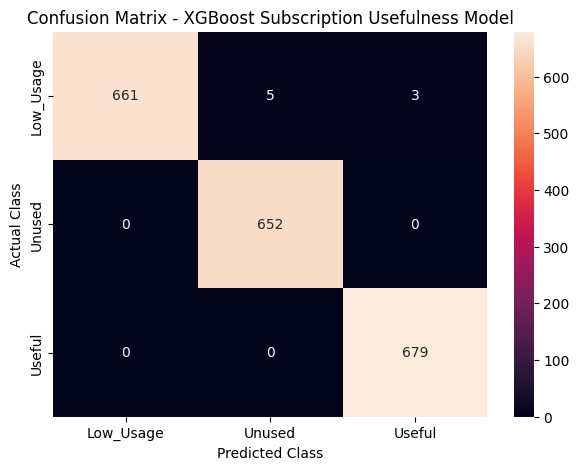

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - XGBoost Subscription Usefulness Model")

plt.show()

In [65]:
from google.colab import files

files.download("subscription_usefulness_xgboost.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>